# XGBoost v6 (Cascade + SMOTE)

This notebook builds on v5 by:

1. Adding SMOTE to generate synthetic cancellation examples before training Model A
2. Lowering scale_pos_weight from 56 to 10: v5 showed 56 was way too aggressive
3. Model B stays exactly the same as v5

v5 got good cancelled recall but precision was terrible (4-5%) and on_time recall dropped a lot. The idea is SMOTE creates better synthetic cancelled examples so the model doesn't have to rely as heavily on the weight multiplier. Lower weight + better synthetic data hopefully means better precision without losing too much recall.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
import sys
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             average_precision_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Data

Same dataset as v5, same splits, same features.

In [3]:
sys.path.append('../../../4_scripts')
from flight_weather_setup import load_data, get_splits

df = load_data()
(X_train_a, y_train_a, X_val_a, y_val_a, X_test_a, y_test_a,
 X_train_b, y_train_b, X_val_b, y_val_b, X_test_b, y_test_b,
 y_val_true, y_test_true, features) = get_splits(df)

if len(X_train_a) > 2_000_000:
    idx = np.random.choice(len(X_train_a), 2_000_000, replace=False)
    X_train_a = X_train_a.iloc[idx]
    y_train_a = y_train_a.iloc[idx]

neg = (y_train_a == 0).sum()
pos = (y_train_a == 1).sum()
scale_pw = round(neg / pos)
print(f'scale_pos_weight = {neg:,} / {pos:,} = {scale_pw}')
print(f'Model A -- train: {X_train_a.shape}, val: {X_val_a.shape}')
print(f'Model B -- train: {X_train_b.shape}, val: {X_val_b.shape}')

Model A -- train: (2000000, 18), val: (6310951, 18)
Model B -- train: (13535123, 18), val: (6199937, 18)


## Model A: Cancellation Prediction (SMOTE + scale_pos_weight=10)

SMOTE first to create synthetic cancelled examples, then scale_pos_weight=10 to give the model a small extra nudge. The key difference from v5 is 10 instead of 56: SMOTE already did most of the balancing work so we don't need to push as hard.

In [4]:
# SMOTE to generate synthetic cancelled examples
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_a_res, y_train_a_res = smote.fit_resample(X_train_a, y_train_a)

print(f'before SMOTE -- cancelled: {y_train_a.sum():,}, not cancelled: {(y_train_a==0).sum():,}')
print(f'after SMOTE  -- cancelled: {y_train_a_res.sum():,}, not cancelled: {(y_train_a_res==0).sum():,}')

# lower scale_pos_weight since SMOTE already helped balance -- 10 instead of 56
model_a = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    scale_pos_weight=10,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_a.fit(X_train_a_res, y_train_a_res,
            eval_set=[(X_val_a, y_val_a)],
            verbose=False)
print('model A done')

before SMOTE -- cancelled: 34,974, not cancelled: 1,965,026
after SMOTE  -- cancelled: 393,005, not cancelled: 1,965,026
model A done


Model A val PR-AUC: 0.0553
               precision    recall  f1-score   support

not_cancelled       0.98      0.99      0.99   6199937
    cancelled       0.11      0.09      0.10    111014

     accuracy                           0.97   6310951
    macro avg       0.55      0.54      0.54   6310951
 weighted avg       0.97      0.97      0.97   6310951



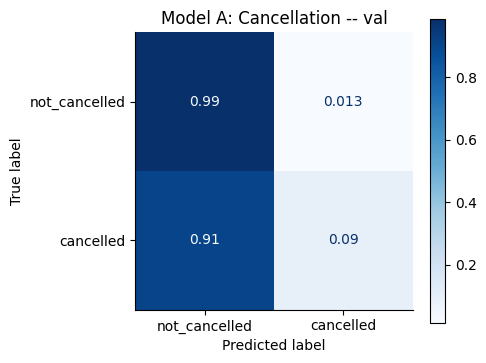

In [5]:
pred_a_val = model_a.predict(X_val_a)
prauc_a = average_precision_score(y_val_a, model_a.predict_proba(X_val_a)[:, 1])

print(f'Model A val PR-AUC: {prauc_a:.4f}')
print(classification_report(y_val_a, pred_a_val,
      target_names=['not_cancelled', 'cancelled'], zero_division=0))

cm_a = confusion_matrix(y_val_a, pred_a_val)
cm_a_norm = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)
fig_a, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_a_norm, display_labels=['not_cancelled', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model A: Cancellation -- val')
plt.tight_layout()
plt.show()

## Model B: Delay Prediction (class weights)

No changes here, same as v5.

In [6]:
weights_b = compute_sample_weight('balanced', y_train_b)

model_b = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_b.fit(X_train_b, y_train_b,
            sample_weight=weights_b,
            eval_set=[(X_val_b, y_val_b)],
            verbose=False)
print('model B done')

model B done


              precision    recall  f1-score   support

     on_time       0.89      0.66      0.76   5127027
     delayed       0.27      0.60      0.37   1072910

    accuracy                           0.65   6199937
   macro avg       0.58      0.63      0.56   6199937
weighted avg       0.78      0.65      0.69   6199937



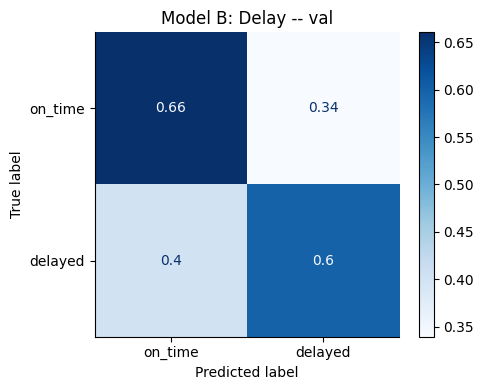

In [7]:
pred_b_val = model_b.predict(X_val_b)
print(classification_report(y_val_b, pred_b_val,
      target_names=['on_time', 'delayed'], zero_division=0))

cm_b = confusion_matrix(y_val_b, pred_b_val)
cm_b_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)
fig_b, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_b_norm, display_labels=['on_time', 'delayed']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model B: Delay -- val')
plt.tight_layout()
plt.show()

## Putting It Together (**Cascade Inference**)

Same two-stage logic as v5.

val cascade macro F1: 0.4035
              precision    recall  f1-score   support

     on_time       0.88      0.66      0.75   5127027
     delayed       0.26      0.57      0.36   1072910
   cancelled       0.11      0.09      0.10    111014

    accuracy                           0.64   6310951
   macro avg       0.42      0.44      0.40   6310951
weighted avg       0.76      0.64      0.67   6310951



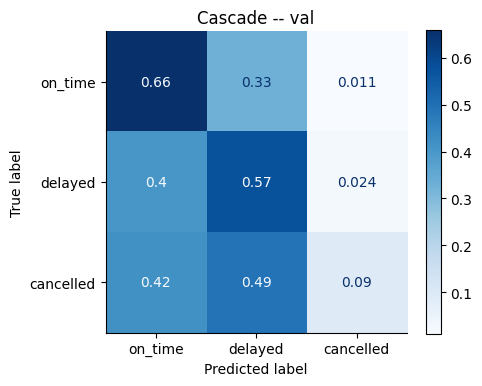

In [8]:
def cascade_predict(X, model_a, model_b, thresh_a=0.5, thresh_b=0.5):
    cancelled = model_a.predict_proba(X)[:, 1] >= thresh_a
    delayed   = model_b.predict_proba(X)[:, 1] >= thresh_b
    return np.where(cancelled, 2, np.where(delayed, 1, 0))

y_val_pred = cascade_predict(X_val_a, model_a, model_b)
mf1_val = f1_score(y_val_true, y_val_pred, average='macro')
print(f'val cascade macro F1: {mf1_val:.4f}')
print(classification_report(y_val_true, y_val_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_val_norm = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
fig_val, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_val_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Cascade -- val')
plt.tight_layout()
plt.show()

## Test Set Results

test cascade macro F1: 0.4152
              precision    recall  f1-score   support

     on_time       0.84      0.62      0.71   3091391
     delayed       0.31      0.61      0.41    863057
   cancelled       0.16      0.11      0.13    123191

    accuracy                           0.60   4077639
   macro avg       0.43      0.44      0.42   4077639
weighted avg       0.71      0.60      0.63   4077639



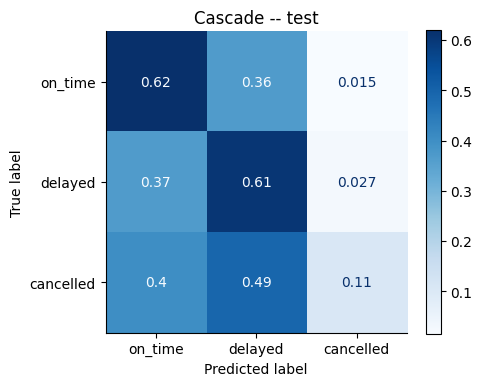

In [9]:
y_test_pred = cascade_predict(X_test_a, model_a, model_b)
mf1_test = f1_score(y_test_true, y_test_pred, average='macro')
print(f'test cascade macro F1: {mf1_test:.4f}')
print(classification_report(y_test_true, y_test_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
fig_test, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_test_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Cascade -- test')
plt.tight_layout()
plt.show()

## v1 through v6 Comparison

Does SMOTE + lower weight finally beat v3?

          model  val macro F1  test macro F1
v1 flights only        0.3054         0.2954
    v2 +weather        0.3641         0.3594
    v3 +weights        0.3750         0.3770
        v4 +spw        0.2795         0.2614
v5 cascade +spw        0.3624         0.3582
 v6 +SMOTE +spw        0.4035         0.4152


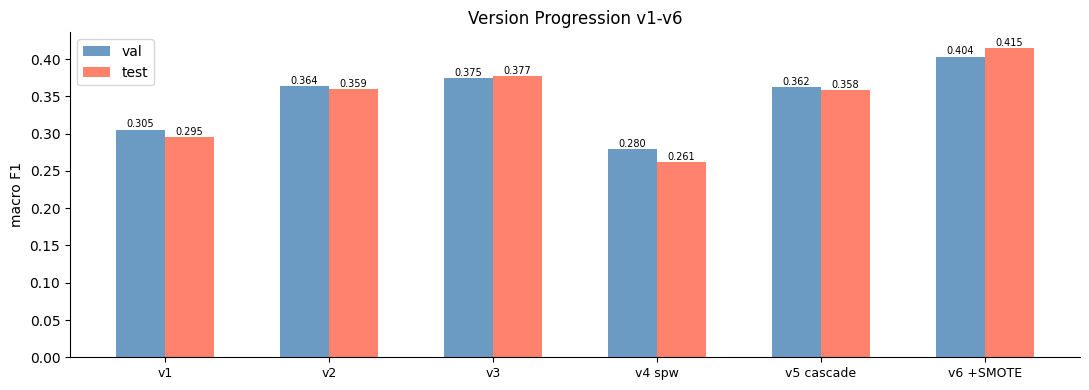

In [10]:
v1_val,  v1_test  = 0.3054, 0.2954
v2_val,  v2_test  = 0.3641, 0.3594
v3_val,  v3_test  = 0.3750, 0.3770
v4_val,  v4_test  = 0.2795, 0.2614
v5_val,  v5_test  = 0.3624, 0.3582

comparison = pd.DataFrame({
    'model':         ['v1 flights only', 'v2 +weather', 'v3 +weights',
                      'v4 +spw', 'v5 cascade +spw', 'v6 +SMOTE +spw'],
    'val macro F1':  [v1_val, v2_val, v3_val, v4_val, v5_val, round(mf1_val,  4)],
    'test macro F1': [v1_test, v2_test, v3_test, v4_test, v5_test, round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

fig_comp, ax = plt.subplots(figsize=(11, 4))
x = np.arange(6)
width = 0.3
vals  = [v1_val, v2_val, v3_val, v4_val, v5_val, mf1_val]
tests = [v1_test, v2_test, v3_test, v4_test, v5_test, mf1_test]
ax.bar(x - width/2, vals,  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, tests, width, label='test', color='tomato',    alpha=0.8)
for i, (v, t) in enumerate(zip(vals, tests)):
    ax.text(i - width/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=7)
    ax.text(i + width/2, t + 0.003, f'{t:.3f}', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(['v1', 'v2', 'v3', 'v4 spw', 'v5 cascade', 'v6 +SMOTE'], fontsize=9)
ax.set_ylabel('macro F1')
ax.set_title('Version Progression v1-v6')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

Finally beat v3: 0.4152 test F1. Cancelled precision went from 4-5% up to 16% while recall stayed at 11%. The SMOTE + lower scale_pos_weight combo found a much better balance than just cranking the weight up like we did in v5.

Next step is v7 where we swap in the new bigger dataset that has lag features and airport operations data.